**Program No. 09.  >> Pivot Table and Pivot Chart**


**Objective:** To summarize and analyze data.
**Tasks:**
- Create a pivot table
- Generate a pivot chart from the dataset

**Outcome:** Students will perform grouped data analysis efficiently.

**Step 1:** Import Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

**Step 2:** Load Dataset : `MMDU_Student_Performance.csv`

In [5]:
# Load dataset
# df = pd.read_csv("MMDU_Student_Performance.csv")
df = pd.read_csv("student_extended.csv")

# Clean column names
df.columns = df.columns.str.strip()

In [6]:
# Clean column names
df.columns = df.columns.str.strip()

# Convert required numeric columns
df["percentage"] = pd.to_numeric(df["percentage"], errors="coerce")
df["sgpa"] = pd.to_numeric(df["sgpa"], errors="coerce")

# Remove missing important values
df = df.dropna(subset=["department", "percentage", "sgpa"])

In [7]:
# Convert required columns to numeric
df["percentage"] = pd.to_numeric(df["percentage"], errors="coerce")
df["study_hours_per_day"] = pd.to_numeric(df["study_hours_per_day"], errors="coerce")

# Drop rows with missing numeric values
df = df.dropna(subset=["percentage", "study_hours_per_day"])

**Step 3:** Create Pivot Table

We will calculate:
- Average Percentage
- Average Study Hours
- Student Count per Specialization

In [8]:
pivot_table = pd.pivot_table(
    df,
    index="department",
    values=["percentage", "sgpa"],
    aggfunc={
        "percentage": "mean",
        "sgpa": "mean"
    }
)

# Add student count
pivot_table["Student Count"] = df.groupby("department").size()

# Round values
pivot_table = pivot_table.round(2)

print("\n--- Department-wise Academic Summary (Pivot Table) ---")
print(pivot_table)


--- Department-wise Academic Summary (Pivot Table) ---
            percentage  sgpa  Student Count
department                                 
BCA              66.57  7.95            219
CSE              66.75  7.91            264
ECE              67.58  8.05            225
IT               67.13  7.98            269
MCA              66.17  8.08            223


In [9]:
pivot_table = pd.pivot_table(
    df,
    index="specialization",
    values=["percentage", "study_hours_per_day"],
    aggfunc=["mean", "count"]
)

print(pivot_table)

                     mean                          count                    
               percentage study_hours_per_day percentage study_hours_per_day
specialization                                                              
AI              65.881034            5.420690        232                 232
Cloud           66.897131            5.653279        244                 244
Cyber Security  68.526805            5.954357        241                 241
Data Science    66.746824            5.481545        233                 233
Software Engg   66.188000            5.426400        250                 250


In [11]:
pivot_table = pd.pivot_table(
    df,
    index="department",
    values=["percentage", "sgpa"],
    aggfunc="mean"
)

# Flatten multi-level columns
pivot_table.columns = pivot_table.columns.get_level_values(0)

# Add student count
pivot_table["student_count"] = df.groupby("department").size()

pivot_table = pivot_table.round(2)

print(pivot_table)

            percentage  sgpa  student_count
department                                 
BCA              66.57  7.95            219
CSE              66.75  7.91            264
ECE              67.58  8.05            225
IT               67.13  7.98            269
MCA              66.17  8.08            223


<Axes: xlabel='department'>

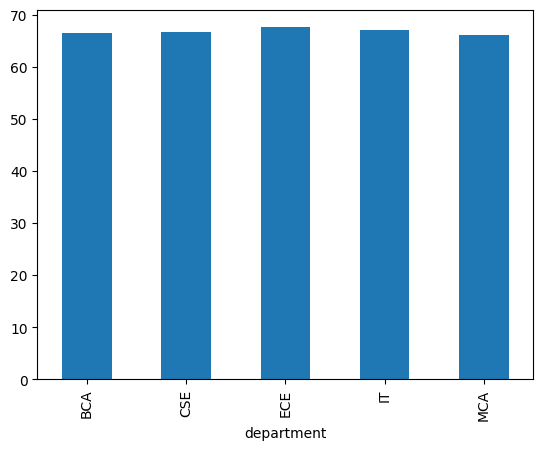

In [12]:
pivot_table["percentage"].plot(kind="bar")

**Step 4:** Create Pivot Chart

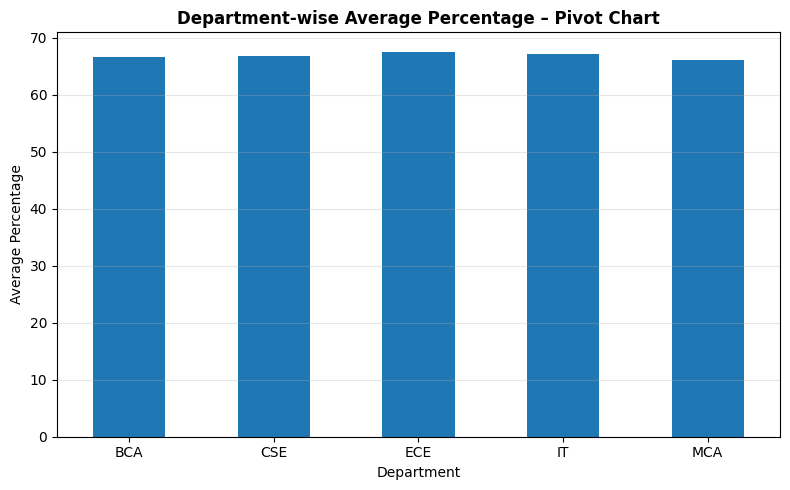

In [13]:
plt.figure(figsize=(8,5))

pivot_table["percentage"].plot(kind="bar")

plt.title("Department-wise Average Percentage – Pivot Chart", fontweight="bold")
plt.xlabel("Department")
plt.ylabel("Average Percentage")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

- Pivot table summarizes student count by department and year.
- Pivot chart visually compares enrollment trends.
- CS department consistently shows highest enrollment.
- Year-wise growth trend is clearly visible.